# <font color="brown">Loan Default Prediction: Does Feature Engineering Help? </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

A bank's consumer lending team has 6,000 recent loan applications, each labeled with whether the applicant ultimately defaulted. They already have a logistic regression model running on the raw application fields (income, loan amount, credit score, and so on), and it works reasonably well. Before investing in a more complex model, the risk team wants to know: can *better features*, built from the same raw data the bank already collects, meaningfully improve the existing model, with no new data collection required?

### <font color="blue"> Objective

- Build a baseline model directly on the raw application fields.
- Engineer new features (a ratio, an interaction/indicator, and interpretable bins) from those same raw fields, and rebuild the model.
- Honestly compare the two, on more than one metric, before recommending anything.

### <font color="blue"> Data Dictionary

- **Applicant_ID**: unique identifier
- **Age**: applicant age in years
- **Annual_Income**: gross annual income (USD)
- **Loan_Amount**: amount requested (USD)
- **Credit_Score**: 300–850
- **Employment_Years**: years at current employer
- **Num_Dependents**: number of financial dependents
- **Existing_Loans**: number of other loans currently open
- **Home_Ownership**: Own / Mortgage / Rent
- **Purpose**: stated loan purpose
- **Default**: 1 if the applicant defaulted, 0 otherwise (target)

## <font color="brown"> Importing Necessary Libraries

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)

%matplotlib inline

## <font color="brown"> Reading and Understanding the Data

In [5]:
df = pd.read_csv("loan_applications.csv")
df.shape

(6000, 11)

In [6]:
df.head()

,Applicant_ID,Age,Annual_Income,Loan_Amount,Credit_Score,Employment_Years,Num_Dependents,Existing_Loans,Home_Ownership,Purpose,Default
0,700001,27,33313.75,8658.87,806,11.8,0,0,Own,Auto,0
1,700002,26,66110.68,28103.22,587,3.9,1,1,Rent,Auto,1
2,700003,56,42544.55,1825.26,718,2.8,1,0,Mortgage,Home_Improvement,0
3,700004,43,88331.14,1000.00,735,6.6,0,0,Own,Debt_Consolidation,0
4,700005,47,28875.21,6581.70,426,5.5,3,1,Mortgage,Auto,1


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Applicant_ID,6000.0,703000.500000,1732.195139,700001.0,701500.7500,703000.500,704500.2500,706000.00
Age,6000.0,43.138667,12.949815,21.0,32.0000,43.500,54.0000,65.00
Annual_Income,6000.0,58607.944973,23371.079049,14000.0,42013.3850,58375.675,74989.4000,150001.34
Loan_Amount,6000.0,16234.645998,9385.827111,1000.0,9143.6525,16023.825,22668.0225,50775.15
Credit_Score,6000.0,648.564500,88.121173,316.0,589.0000,650.500,707.0000,850.00
Employment_Years,6000.0,7.210300,4.639462,0.0,3.7000,7.000,10.4000,31.40
Num_Dependents,6000.0,2.008000,1.415840,0.0,1.0000,2.000,3.0000,4.00
Existing_Loans,6000.0,1.477167,1.118192,0.0,0.0000,1.000,2.0000,3.00
Default,6000.0,0.308167,0.461774,0.0,0.0000,0.000,1.0000,1.00


In [8]:
df.isnull().sum()

Applicant_ID        0
Age                 0
Annual_Income       0
Loan_Amount         0
Credit_Score        0
Employment_Years    0
Num_Dependents      0
Existing_Loans      0
Home_Ownership      0
Purpose             0
Default             0
dtype: int64

No missing values. Checking how imbalanced the target is:

In [10]:
df["Default"].value_counts(normalize=True).round(3)

Default
0    0.692
1    0.308
Name: proportion, dtype: float64

**About 31% of applicants in this dataset defaulted**, imbalanced enough that accuracy alone would be a misleading metric, we'll track recall, precision, F1, and AUC throughout, the same discipline used in the earlier classification case studies.

### <font color="blue"> A Quick Look at the Raw Fields

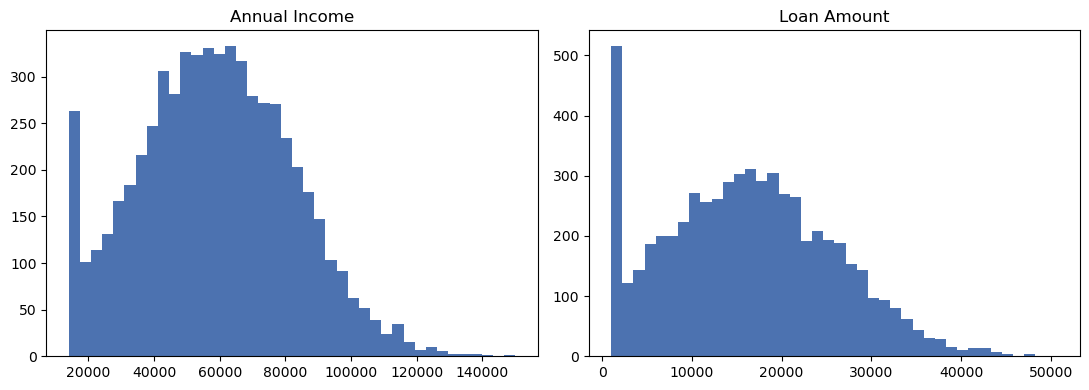

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Annual_Income"], bins=40, color="#4C72B0")
axes[0].set_title("Annual Income")
axes[1].hist(df["Loan_Amount"], bins=40, color="#4C72B0")
axes[1].set_title("Loan Amount")
plt.tight_layout()
plt.show()

Both are right-skewed, as income and loan amounts typically are. On their own, neither variable obviously separates defaulters from non-defaulters:

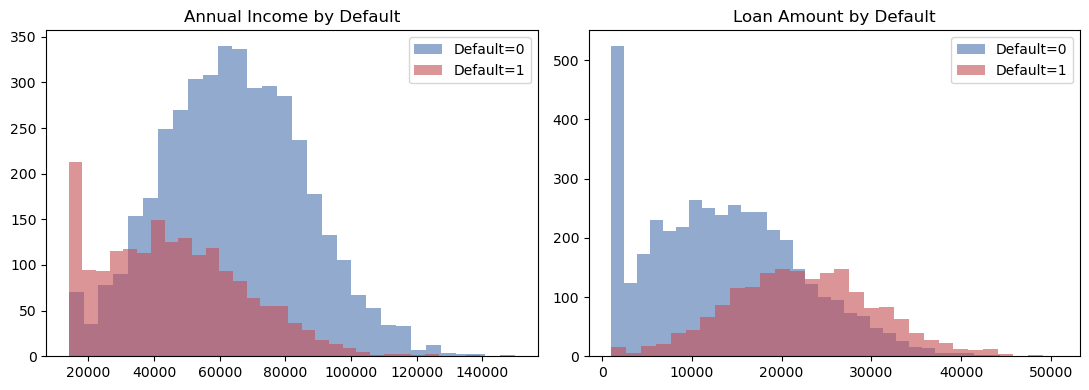

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    subset = df[df["Default"] == label]
    axes[0].hist(subset["Annual_Income"], bins=30, alpha=0.6, color=color, label=f"Default={label}")
    axes[1].hist(subset["Loan_Amount"], bins=30, alpha=0.6, color=color, label=f"Default={label}")
axes[0].set_title("Annual Income by Default"); axes[0].legend()
axes[1].set_title("Loan Amount by Default"); axes[1].legend()
plt.tight_layout()
plt.show()

The distributions overlap heavily in both plots, defaulters and non-defaulters aren't clearly separated by income or loan amount individually. That's a hint (not yet proof) that what matters might be the *relationship between* these two numbers, rather than either one alone, exactly the kind of pattern raw linear features struggle to represent.

## <font color="brown"> Part 1: Baseline Model on Raw Fields

In [18]:
cat_cols = ["Home_Ownership", "Purpose"]
X_raw = df.drop(columns=["Applicant_ID", "Default"])
X_raw = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True, dtype=int)
y = df["Default"]

X_raw.head()

,Age,Annual_Income,Loan_Amount,Credit_Score,Employment_Years,Num_Dependents,Existing_Loans,Home_Ownership_Own,Home_Ownership_Rent,Purpose_Debt_Consolidation,Purpose_Home_Improvement,Purpose_Medical,Purpose_Other
0,27,33313.75,8658.87,806,11.8,0,0,1,0,0,0,0,0
1,26,66110.68,28103.22,587,3.9,1,1,0,1,0,0,0,0
2,56,42544.55,1825.26,718,2.8,1,0,0,0,0,1,0,0
3,43,88331.14,1000.00,735,6.6,0,0,1,0,1,0,0,0
4,47,28875.21,6581.70,426,5.5,3,1,0,0,0,0,0,0


In [19]:
X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=1, stratify=y
)

scaler_raw = StandardScaler().fit(X_raw_train)
X_raw_train_scaled = scaler_raw.transform(X_raw_train)
X_raw_test_scaled = scaler_raw.transform(X_raw_test)

In [20]:
lr_raw = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=1)
lr_raw.fit(X_raw_train_scaled, y_train)

pred_raw = lr_raw.predict(X_raw_test_scaled)
proba_raw = lr_raw.predict_proba(X_raw_test_scaled)[:, 1]

raw_metrics = {
    "Recall": recall_score(y_test, pred_raw),
    "Precision": precision_score(y_test, pred_raw),
    "F1": f1_score(y_test, pred_raw),
    "AUC": roc_auc_score(y_test, proba_raw),
}
raw_metrics

{'Recall': 0.8108108108108109,
 'Precision': 0.6598240469208211,
 'F1': 0.7275666936135813,
 'AUC': 0.9015015015015015}

## <font color="brown"> Part 2: Engineering New Features

We add three kinds of features, all built purely from columns the bank already has, no new data collection required:

### <font color="blue"> 1. A Ratio Feature: Debt-to-Income (DTI)

A logistic regression is a *linear* model, it can weigh `Loan_Amount` and `Annual_Income` separately, but it cannot represent their **ratio** just by combining them linearly. If what actually drives risk is how large the loan is *relative to* income, rather than either number in isolation, the raw model structurally cannot see that, no matter how much data it's given. Computing the ratio explicitly hands it directly to the model:

In [25]:
df["DTI"] = (df["Loan_Amount"] / df["Annual_Income"]).round(4)
df[["Loan_Amount", "Annual_Income", "DTI", "Default"]].head()

,Loan_Amount,Annual_Income,DTI,Default
0,8658.87,33313.75,0.2599,0
1,28103.22,66110.68,0.4251,1
2,1825.26,42544.55,0.0429,0
3,1000.00,88331.14,0.0113,0
4,6581.70,28875.21,0.2279,1


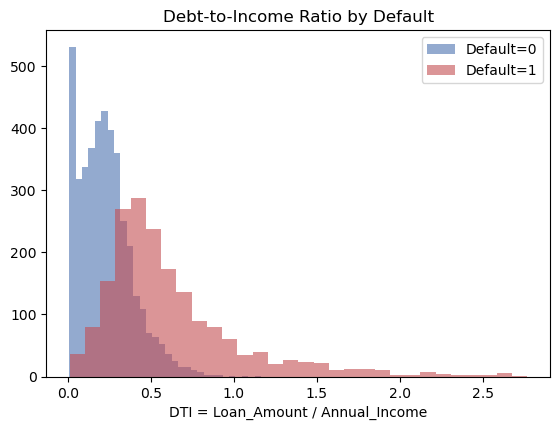

In [26]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    subset = df[df["Default"] == label]
    ax.hist(subset["DTI"], bins=30, alpha=0.6, color=color, label=f"Default={label}")
ax.set_title("Debt-to-Income Ratio by Default")
ax.set_xlabel("DTI = Loan_Amount / Annual_Income")
ax.legend()
plt.show()

Unlike the individual income and loan-amount plots earlier, DTI shows a real, visible split, defaulters skew noticeably higher.

### <font color="blue"> 2. An Interaction Feature: High-Risk Combination

A linear model also can't represent an **AND** condition, “high DTI *and* poor credit score, together, is much worse than either alone” is a genuinely nonlinear interaction. We make it explicit as a 0/1 flag:

In [30]:
df["High_Risk_Combo"] = ((df["DTI"] > 0.35) & (df["Credit_Score"] < 600)).astype(int)
df["High_Risk_Combo"].value_counts()

High_Risk_Combo
0    5382
1     618
Name: count, dtype: int64

In [31]:
combo_default_rate = df.groupby("High_Risk_Combo")["Default"].mean().round(3)
combo_default_rate

High_Risk_Combo
0    0.230
1    0.987
Name: Default, dtype: float64

Applicants flagged `High_Risk_Combo=1` default far more often than the rest, exactly the kind of signal a linear model can only use once it's hand-built into a single feature.

### <font color="blue"> 3. Interpretable Bins: Credit Score Bands

Separately from the two performance-driven features above, we also bin `Credit_Score` into the standard, business-familiar bands lenders already talk about. This isn't expected to add predictive power on its own (the raw score is already numeric and informative), it's about making the model's behavior easier to explain to a non-technical audience.

In [35]:
df["Credit_Band"] = pd.cut(
    df["Credit_Score"], bins=[299, 579, 669, 739, 850],
    labels=["Poor", "Fair", "Good", "Excellent"]
)
df[["Credit_Score", "Credit_Band"]].head()

,Credit_Score,Credit_Band
0,806,Excellent
1,587,Fair
2,718,Good
3,735,Good
4,426,Poor


In [36]:
df.groupby("Credit_Band", observed=True)["Default"].mean().round(3)

Credit_Band
Poor         0.516
Fair         0.311
Good         0.222
Excellent    0.148
Name: Default, dtype: float64

Default rate drops steadily from Poor to Excellent, confirming the bands track real risk, useful context even though the numeric `Credit_Score` will remain in the model too.

## <font color="brown"> Part 3: Rebuilding the Model with Engineered Features

In [39]:
fe_cols_to_add = ["DTI", "High_Risk_Combo"]
X_fe = df.drop(columns=["Applicant_ID", "Default", "Credit_Band"])
X_fe = pd.get_dummies(X_fe, columns=cat_cols, drop_first=True, dtype=int)
X_fe.head()

,Age,Annual_Income,Loan_Amount,Credit_Score,Employment_Years,Num_Dependents,Existing_Loans,DTI,High_Risk_Combo,Home_Ownership_Own,Home_Ownership_Rent,Purpose_Debt_Consolidation,Purpose_Home_Improvement,Purpose_Medical,Purpose_Other
0,27,33313.75,8658.87,806,11.8,0,0,0.2599,0,1,0,0,0,0,0
1,26,66110.68,28103.22,587,3.9,1,1,0.4251,1,0,1,0,0,0,0
2,56,42544.55,1825.26,718,2.8,1,0,0.0429,0,0,0,0,1,0,0
3,43,88331.14,1000.00,735,6.6,0,0,0.0113,0,1,0,1,0,0,0
4,47,28875.21,6581.70,426,5.5,3,1,0.2279,0,0,0,0,0,0,0


In [40]:
X_fe_train, X_fe_test, y_train2, y_test2 = train_test_split(
    X_fe, y, test_size=0.3, random_state=1, stratify=y
)

scaler_fe = StandardScaler().fit(X_fe_train)
X_fe_train_scaled = scaler_fe.transform(X_fe_train)
X_fe_test_scaled = scaler_fe.transform(X_fe_test)

In [41]:
lr_fe = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=1)
lr_fe.fit(X_fe_train_scaled, y_train2)

pred_fe = lr_fe.predict(X_fe_test_scaled)
proba_fe = lr_fe.predict_proba(X_fe_test_scaled)[:, 1]

fe_metrics = {
    "Recall": recall_score(y_test2, pred_fe),
    "Precision": precision_score(y_test2, pred_fe),
    "F1": f1_score(y_test2, pred_fe),
    "AUC": roc_auc_score(y_test2, proba_fe),
}
fe_metrics

{'Recall': 0.7801801801801802,
 'Precision': 0.7389078498293515,
 'F1': 0.7589833479404031,
 'AUC': 0.9105076160497848}

## <font color="brown"> Comparing the Two Models, Honestly

In [43]:
comparison = pd.DataFrame([raw_metrics, fe_metrics], index=["Raw Features", "Engineered Features"]).round(3)
comparison

,Recall,Precision,F1,AUC
Raw Features,0.811,0.660,0.728,0.902
Engineered Features,0.780,0.739,0.759,0.911


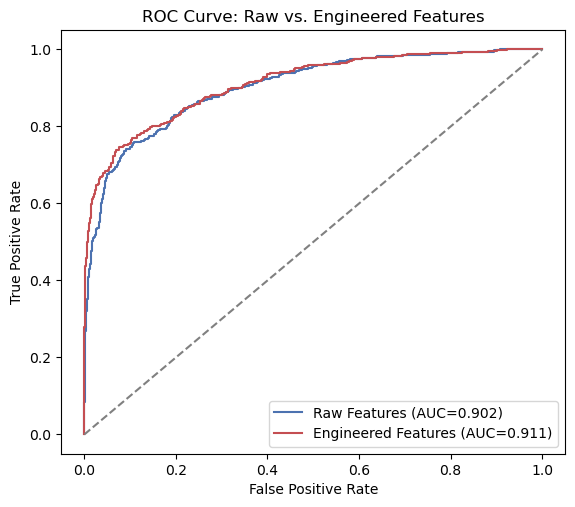

In [44]:
fpr_raw, tpr_raw, _ = roc_curve(y_test, proba_raw)
fpr_fe, tpr_fe, _ = roc_curve(y_test2, proba_fe)

plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr_raw, tpr_raw, label=f"Raw Features (AUC={raw_metrics['AUC']:.3f})", color="#4C72B0")
plt.plot(fpr_fe, tpr_fe, label=f"Engineered Features (AUC={fe_metrics['AUC']:.3f})", color="#C44E52")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Raw vs. Engineered Features")
plt.legend()
plt.show()

**AUC improves from 0.902 to 0.911, and F1 improves from 0.728 to 0.759, both real, if modest, gains from features built out of data the bank already had.** At the fixed default classification threshold used here, recall and precision shift places (recall goes down slightly, precision goes up more), which is worth being upfront about rather than glossing over. AUC is the more relevant metric for judging this: it measures how well the model *ranks* risky applicants above safe ones regardless of where the bank sets its approval cutoff, and on that measure the engineered-feature model is unambiguously better. A bank can always move the threshold to trade recall for precision however its risk appetite demands, that's a business decision layered on top of a model that is now genuinely better at separating the two classes.

### <font color="blue"> Which Features Is the Model Actually Leaning On?

In [47]:
coef_df = pd.DataFrame({
    "Feature": X_fe.columns,
    "Coefficient": lr_fe.coef_[0],
}).sort_values("Coefficient", key=abs, ascending=False)
coef_df.head(8)

,Feature,Coefficient
7,DTI,2.502984
8,High_Risk_Combo,0.975755
3,Credit_Score,-0.959719
13,Purpose_Medical,-0.112376
11,Purpose_Debt_Consolidation,0.098384
4,Employment_Years,-0.097261
10,Home_Ownership_Rent,0.078900
6,Existing_Loans,0.059753


`DTI` and `High_Risk_Combo`, the two features that didn't exist in the raw dataset, rank among the model's strongest predictors, direct, verifiable evidence that the improvement above is coming from the engineered features themselves, not from noise or an artifact of the train/test split.

## <font color="brown"> Business Insights and Recommendations

- **Feature engineering measurably improved the model, using only data the bank already collects.** AUC rose from 0.902 to 0.911 and F1 from 0.728 to 0.759, with zero new data collection cost.

- **The gain came specifically from representing a ratio and an interaction that a linear model cannot construct on its own.** `DTI` (loan-to-income ratio) and `High_Risk_Combo` (high DTI stacked with poor credit) both rank among the model's most influential features, confirming the improvement is real and traceable, not incidental.

- **Recall and precision shifted at the current threshold, worth flagging honestly to stakeholders rather than only reporting the metrics that improved.** Because AUC improved, the bank can recover any recall level it wants (including matching the old model's recall exactly) by adjusting the approval threshold, and will get better precision at that recall than the raw model could offer.

- **Credit_Band, while not shown to add predictive power here, is still worth keeping in reporting and dashboards.** Loan officers and regulators think in Poor/Fair/Good/Excellent bands, not raw scores, keeping both the interpretable version and the numeric version serves different audiences.

- **This same pattern, look for ratios and interactions the raw fields imply but don't state directly, is worth applying to other bank models built on raw fields alone (e.g. the earlier SVM and Naive Bayes case studies), it is often one of the cheapest ways to improve a model, no new data required.